In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\UTKARSH SINGH\OneDrive\Desktop\Data Science\Retail-Store-Transactions.csv")

In [3]:
df

,Date,Time,StoreID,Location,Product,Quantity,UnitPrice,PaymentType,TransactionID,Cashier,StoreManager,TimeOfDay,DayOfWeek,TotalPrice
0,2024-03-30,15:29,S3,Store C,Tablet,3,364.22,Gift Card,TX300000,C1,Noah,Afternoon,Saturday,1092.66
1,2023-03-16,16:53,S1,Store B,Printer,9,384.74,Online,TX300001,C5,Liam,Afternoon,Thursday,3462.66
2,2024-04-26,21:22,S9,Store B,Laptop,9,397.80,Debit Card,TX300002,C3,Liam,Evening,Friday,3580.20
3,2025-02-08,14:28,S9,Store C,Monitor,7,80.27,Online,TX300003,C2,Mia,Afternoon,Saturday,561.89
4,2024-06-17,20:00,S9,Store A,Monitor,10,214.03,Gift Card,TX300004,C1,Noah,Evening,Monday,2140.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,2024-06-05,21:37,S5,Store B,Phone,9,138.02,Gift Card,TX301995,C1,Olivia,Evening,Wednesday,1242.18
1996,2025-02-26,9:10,S1,Store A,Desk,7,242.35,Cash,TX301996,C4,Liam,Morning,Wednesday,1696.45
1997,2024-05-19,21:11,S9,Store A,Phone,1,297.65,Online,TX301997,C5,Liam,Evening,Sunday,297.65
1998,2023-06-13,13:25,S1,Store A,Desk,1,343.54,Debit Card,TX301998,C2,Olivia,Afternoon,Tuesday,343.54


In [4]:
df.isnull().sum()

Date             0
Time             0
StoreID          0
Location         0
Product          0
Quantity         0
UnitPrice        0
PaymentType      0
TransactionID    0
Cashier          0
StoreManager     0
TimeOfDay        0
DayOfWeek        0
TotalPrice       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           2000 non-null   object 
 1   Time           2000 non-null   object 
 2   StoreID        2000 non-null   object 
 3   Location       2000 non-null   object 
 4   Product        2000 non-null   object 
 5   Quantity       2000 non-null   int64  
 6   UnitPrice      2000 non-null   float64
 7   PaymentType    2000 non-null   object 
 8   TransactionID  2000 non-null   object 
 9   Cashier        2000 non-null   object 
 10  StoreManager   2000 non-null   object 
 11  TimeOfDay      2000 non-null   object 
 12  DayOfWeek      2000 non-null   object 
 13  TotalPrice     2000 non-null   float64
dtypes: float64(2), int64(1), object(11)
memory usage: 218.9+ KB


In [7]:
df['Date']=pd.to_datetime(df['Date'],errors='coerce')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           2000 non-null   datetime64[ns]
 1   Time           2000 non-null   object        
 2   StoreID        2000 non-null   object        
 3   Location       2000 non-null   object        
 4   Product        2000 non-null   object        
 5   Quantity       2000 non-null   int64         
 6   UnitPrice      2000 non-null   float64       
 7   PaymentType    2000 non-null   object        
 8   TransactionID  2000 non-null   object        
 9   Cashier        2000 non-null   object        
 10  StoreManager   2000 non-null   object        
 11  TimeOfDay      2000 non-null   object        
 12  DayOfWeek      2000 non-null   object        
 13  TotalPrice     2000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(10)
memory usage: 218

<Axes: xlabel='Product', ylabel='Count'>

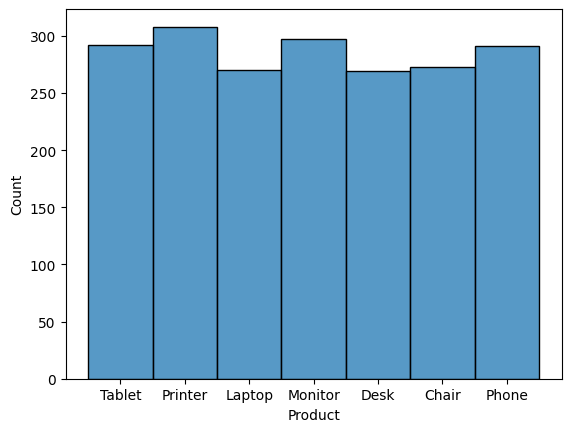

In [9]:
sns.histplot(df['Product'])

<BarContainer object of 2000 artists>

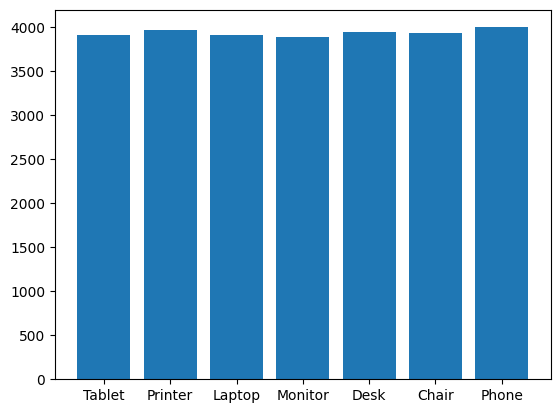

In [10]:
plt.bar(df['Product'],df['TotalPrice'])

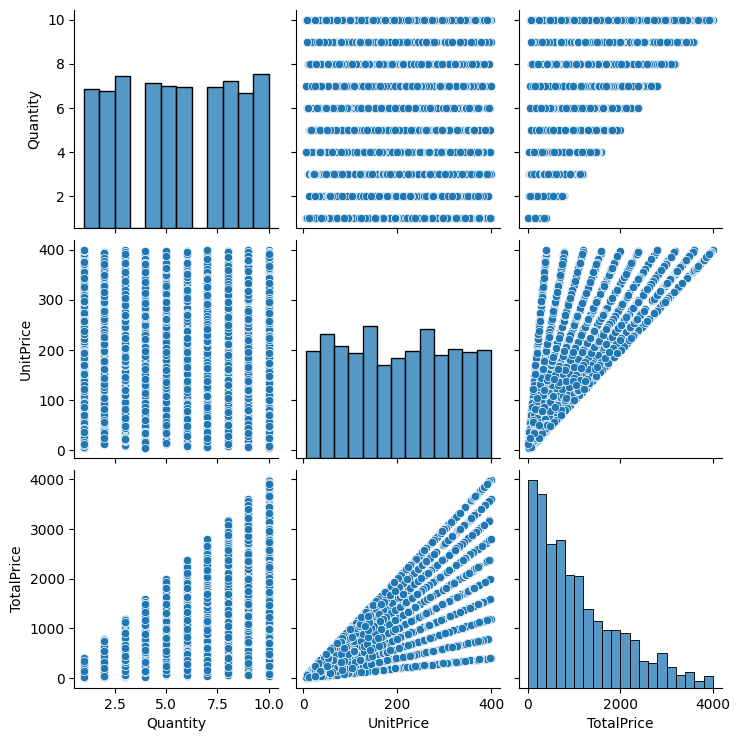

In [11]:
sns.pairplot(df)

In [24]:
x=df.pivot_table(index='Product',columns='Location',values='Quantity',aggfunc='count')

<Axes: xlabel='Location', ylabel='Product'>

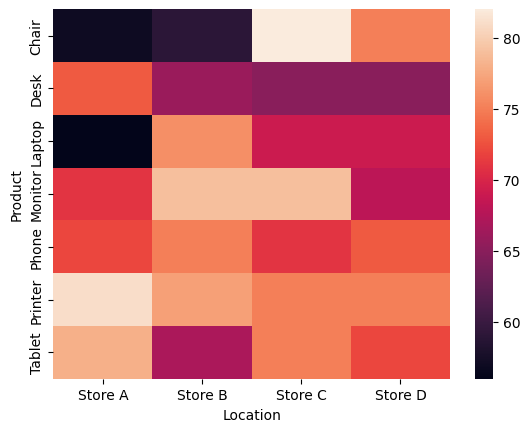

In [25]:
sns.heatmap(x)

In [26]:
y=df.pivot_table(index='Product',columns='Location',values='TotalPrice',aggfunc='sum')

In [27]:
y

Location,Store A,Store B,Store C,Store D
Product,,,,
Chair,61291.39,73472.26,92929.69,91748.81
Desk,77323.10,77370.60,72378.43,66206.47
Laptop,55653.40,79032.09,85170.63,65407.09
Monitor,80317.39,91722.05,103761.33,72194.87
Phone,74658.71,82309.33,77787.69,91455.48
Printer,95634.26,69509.45,81388.77,79052.47
Tablet,77423.91,64976.35,81592.50,85875.03


<Axes: xlabel='Location', ylabel='Product'>

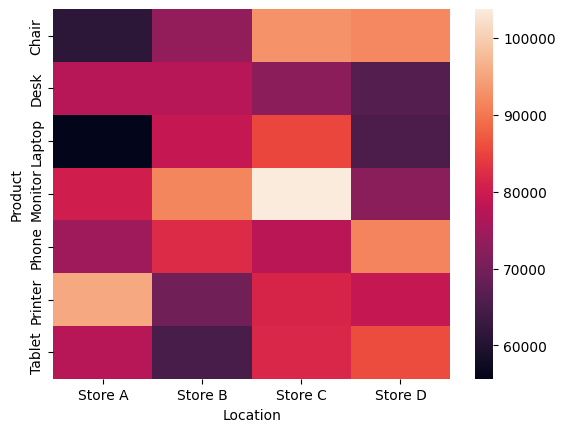

In [28]:
sns.heatmap(y)

In [29]:
z=df.pivot_table(index='Product',columns='PaymentType',values='Quantity',aggfunc='count')

In [30]:
z

PaymentType,Cash,Credit Card,Debit Card,Gift Card,Online
Product,,,,,
Chair,66,51,66,43,47
Desk,48,52,72,50,47
Laptop,44,61,58,52,55
Monitor,59,65,54,60,59
Phone,48,60,68,54,61
Printer,72,60,62,54,60
Tablet,62,61,57,52,60


<Axes: xlabel='PaymentType', ylabel='Product'>

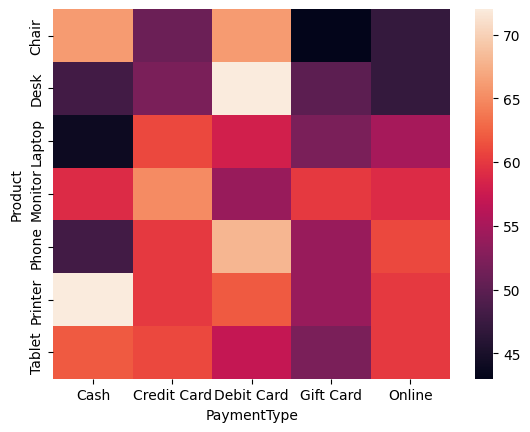

In [31]:
sns.heatmap(z)